<a href="https://colab.research.google.com/github/tojotk/fake_vs_real_news_detection/blob/main/fake_vs_real_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Libraries

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.calibration import CalibratedClassifierCV
import pickle


# Read Data Set

In [111]:
filepath = "/content/drive/MyDrive/Ict_Exam/data"
df_true = f"{filepath}/True.csv"
df_fake = f"{filepath}/Fake.csv"

In [112]:
df_true = pd.read_csv(df_true)
df_fake = pd.read_csv(df_fake)

# EDA

In [113]:
df_true.shape #rows and columns

(21417, 4)

In [114]:
df_fake.shape #rows and columns


(23481, 4)

In [115]:
df_true.head() #for displaying the first 5 rows and colums

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [116]:
df_fake.head()  #for displaying the first 5 rows and colums

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [117]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [118]:
df_fake.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [119]:
df_true.describe() #statistical summary

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [120]:
df_fake.describe() #statistical summary

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


#Task 1 : text exploration

In [121]:
df_true["label"] = 1
df_fake["label"] = 0

In [122]:
#combine both dataset together

In [123]:
df_news = pd.concat([df_true, df_fake], ignore_index=True)
df_news = df_news.sample(frac=1, random_state=42).reset_index(drop=True)

In [124]:
df_news.shape

(44898, 5)

In [125]:
df_news["label"].value_counts()

,count
label,
0,23481
1,21417


In [126]:
df_news["label"].value_counts(normalize=True) * 100 # two class distrubution

,proportion
label,
0,52.298543
1,47.701457


### visualization

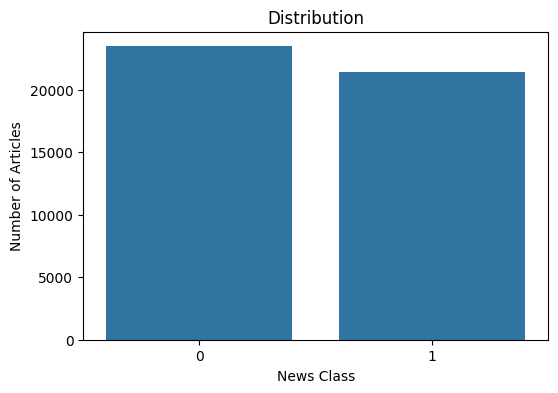

In [127]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_news,x="label")
plt.title("Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")
plt.show()

### data cleaning

In [128]:
df_news.isnull().sum() #missing valus

,0
title,0
text,0
subject,0
date,0
label,0


In [129]:
df_news.duplicated().sum() #check duplicates

np.int64(209)

In [130]:
df_news = df_news.drop_duplicates() #remove duplicates

In [131]:
df_news.shape

(44689, 5)

In [132]:
df_news.duplicated().sum()

np.int64(0)

### article length

In [133]:
#article number of words
df_news["article_length"] = df_news["text"].astype(str).apply(
    lambda x: len(x.split()))
df_news[["text","article_length","label"]].head()

,text,article_length,label
0,"Donald Trump s White House is in chaos, and th...",361,0
1,Now that Donald Trump is the presumptive GOP n...,495,0
2,Mike Pence is a huge homophobe. He supports ex...,379,0
3,SAN FRANCISCO (Reuters) - California Attorney ...,88,1
4,Twisted reasoning is all that comes from Pelos...,138,0


In [134]:
#compare fake vs real
df_news.groupby("label")["article_length"].agg(
    ["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
label,,,,,
0,23478,423.224167,363.0,0,8135
1,21211,384.757484,359.0,0,5172


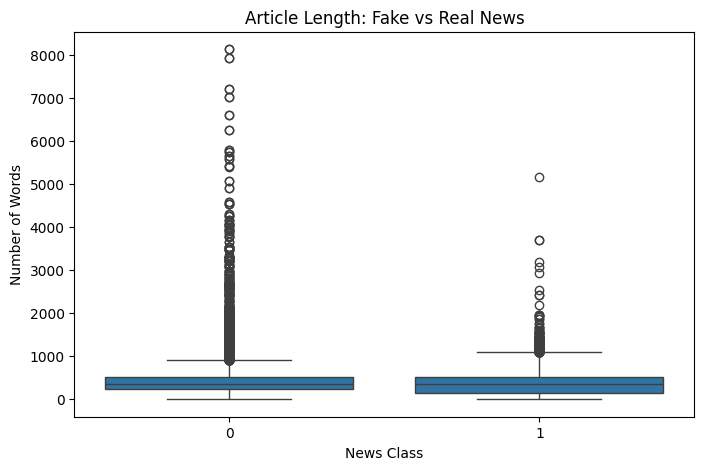

In [135]:
#visualization of articlelength
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_news,
    x="label",
    y="article_length"
)
plt.title("Article Length: Fake vs Real News")
plt.xlabel("News Class")
plt.ylabel("Number of Words")
plt.show()

### vocabulry

In [136]:
#vocabulry size
#combine all article text
all_text = " ".join(df_news["text"].astype(str))
#to lowercase and split into words
words = all_text.lower().split()
#count unique words
vocabulry_size = len(set(words))
print(vocabulry_size)

362593


In [137]:
#remopve punctutation
clean_text = all_text.lower()
clean_text = re.sub(r"[^\w\s]", "", clean_text)
words = clean_text.split()
vocabulry_size = len(set(words))
print(vocabulry_size)

227826


### word frequency

In [138]:
#word frequency
word_frequency = Counter(words)
print("Top 5 repeat Words:")
word_frequency.most_common(5)

Top 5 repeat Words:


[('the', 1002884),
 ('to', 531739),
 ('of', 438265),
 ('a', 405726),
 ('and', 403808)]

In [139]:
rep_df = pd.DataFrame(
    word_frequency.most_common(5),
    columns=["Word","Frequency"])

In [140]:
rep_df

,Word,Frequency
0,the,1002884
1,to,531739
2,of,438265
3,a,405726
4,and,403808


In [141]:
#removecommon stopwords
filtered_words = [
    word for word in words
    if word not in ENGLISH_STOP_WORDS]
word_frequency = Counter(filtered_words)
rep_df = pd.DataFrame(
    word_frequency.most_common(5),
    columns=["Word","Frequency"])

In [142]:
# 1 : article is fake or true because there is considerable variation within both classes
# 2 : data can contain punctuation,repeat words,spelling diff,irrelevant words etc
# 3: imbalanced dataset can cause a model to favor the more class

# Task 2: NLP preprocessing

###clean and preprocss text

In [143]:
def clean_text(text):
    #convert to lowercase
    text = text.lower()
    #remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    #remove htmltags
    text = re.sub(r"<.*?>", "", text)
    #remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    #remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [144]:
df_news["clean_text"] = df_news["text"].astype(str).apply(clean_text)
df_news[["text","clean_text"]].head()

,text,clean_text
0,"Donald Trump s White House is in chaos, and th...",donald trump s white house is in chaos and the...
1,Now that Donald Trump is the presumptive GOP n...,now that donald trump is the presumptive gop n...
2,Mike Pence is a huge homophobe. He supports ex...,mike pence is a huge homophobe he supports exg...
3,SAN FRANCISCO (Reuters) - California Attorney ...,san francisco reuters california attorney gene...
4,Twisted reasoning is all that comes from Pelos...,twisted reasoning is all that comes from pelos...


### remove stopwords

In [163]:
#TF-IDF vectorization
tfidf = TfidfVectorizer(
    stop_words = "english",
    max_features = 50000,
    ngram_range = (1, 2))
y = df_news["label"]
print(X.shape)

(44689, 50000)


## train test split

In [164]:
X_text = df_news["clean_text"]
y = df_news["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

In [165]:
tfidf = TfidfVectorizer(
    stop_words = "english",
    max_features = 50000,
    ngram_range = (1, 2)
)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [166]:
# 1: stop words removal
# 2: reduces the number of feature
# 3: no

# Task 3: Ml model development

### Classification Models


In [167]:
three_class_models = {
    "Logistic Regression": LogisticRegression(max_iter = 1000, random_state = 42),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state= 42)
}

In [153]:
#training
results = []
for name, model in three_class_models.items():
    #train
    model.fit(X_train, y_train)
    #prediction
    y_pred = model.predict(X_test)
    accuracy= accuracy_score(y_test, y_pred)
    precision= precision_score(y_test, y_pred)
    recall= recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model" : name,
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1 Score" : f1
    })

print("Model evaluation completed.")

Model evaluation completed.


In [154]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.987357,0.985194,0.988213,0.986701
1,Naive Bayes,0.952226,0.954059,0.944837,0.949426
2,Linear SVM,0.994853,0.994345,0.994814,0.994579


#Task 4: error analysis & model intrepretation

### confusion matrix

In [155]:
for name, model in three_class_models.items():
    y_pred = model.predict(X_test)
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("\n", name)
    print(conf_matrix)


 Logistic Regression
[[4633   63]
 [  50 4192]]

 Naive Bayes
[[4503  193]
 [ 234 4008]]

 Linear SVM
[[4672   24]
 [  22 4220]]


### error analysis

In [156]:
#selected the best performing model
final_model = three_class_models["Linear SVM"]
#prediction
y_pred = final_model.predict(X_test)
#create error analysis dataframe
error_df = pd.DataFrame({
    "article": X_test_text.reset_index(drop=True),
    "actual": y_test.reset_index(drop=True),
    "predicted": y_pred
})
# keep only misclassified articles
misclassified = error_df[
    error_df["actual"] != error_df["predicted"]].copy()

print("Total misclassified articles:", len(misclassified))

Total misclassified articles: 46


In [157]:
#analyze 15 misclasified articles
for i, (_, row) in enumerate(misclassified.head(15).iterrows(), start=1):
    actual_label = "Real" if row["actual"] == 1 else "Fake"
    predicted_label = "Real" if row["predicted"] == 1 else "Fake"
    print("=" * 80)
    print(f"Article {i}")
    print(f"Actual: {actual_label}")
    print(f"Predicted: {predicted_label}")
    print("-" * 80)
    print(row["article"][:1000])
    print()

Article 1
Actual: Real
Predicted: Fake
--------------------------------------------------------------------------------
washington reuters a ku klux klan newspaper has declared support for donald trump’s republican run for us president saying america became great because it was a white christian republic the crusader one of the white supremacist group’s most prominent publications published a lengthy endorsement and defense of trump’s message on the front page of its current issue under the headline “make america great again” “make america great again” is trump’s campaign slogan the trump campaign rejected the group’s support in a statement campaign spokesman steven cheung said “mr trump and the campaign denounces hate in any form this publication is repulsive and their views do not represent the tens of millions of americans who are uniting behind our campaign” the kkk is the oldest white supremacist group in the united states tracing its roots back to the reconstruction period in the

In [158]:
# feature importance
feature_names = tfidf.get_feature_names_out()
coeff = final_model.coef_[0]
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coeff
})

In [159]:
top_fake = feature_importance.sort_values("coefficient").head(20)

top_fake

,feature,coefficient
20517,image,-3.352903
33290,president trump,-2.797299
22864,just,-2.643533
17971,gop,-2.251689
27888,mr,-2.140065
38636,saidthe,-2.098848
35732,rep,-2.036225
19661,hillary,-2.008318
20562,images,-1.888998
39662,sen,-1.879681


In [160]:
top_real = feature_importance.sort_values("coefficient", ascending= False).head(20)
top_real

,feature,coefficient
36516,reuters,17.228560
37749,said,6.643653
48378,washington reuters,5.726151
33185,president donald,2.897776
36650,reuters president,2.716058
46362,tuesday,2.324182
29209,nov,2.260722
48598,wednesday,2.252700
49849,york reuters,2.226740
44378,thursday,2.075392


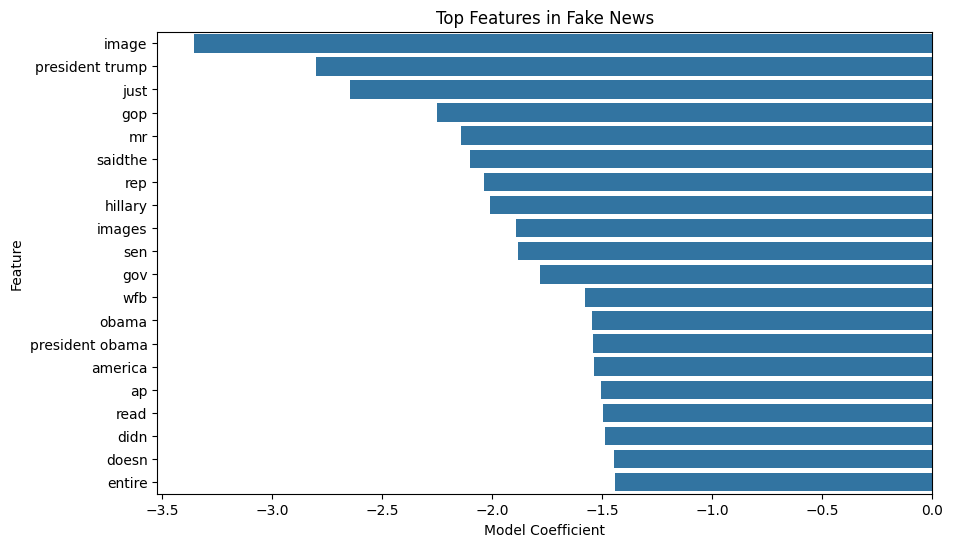

In [161]:
# visualize fake news
plt.figure(figsize= (10,6))
sns.barplot(
    data=top_fake,
    x = "coefficient",
    y = "feature")
plt.title("Top Features in Fake News")
plt.xlabel("Model Coefficient")
plt.ylabel("Feature")

plt.show()

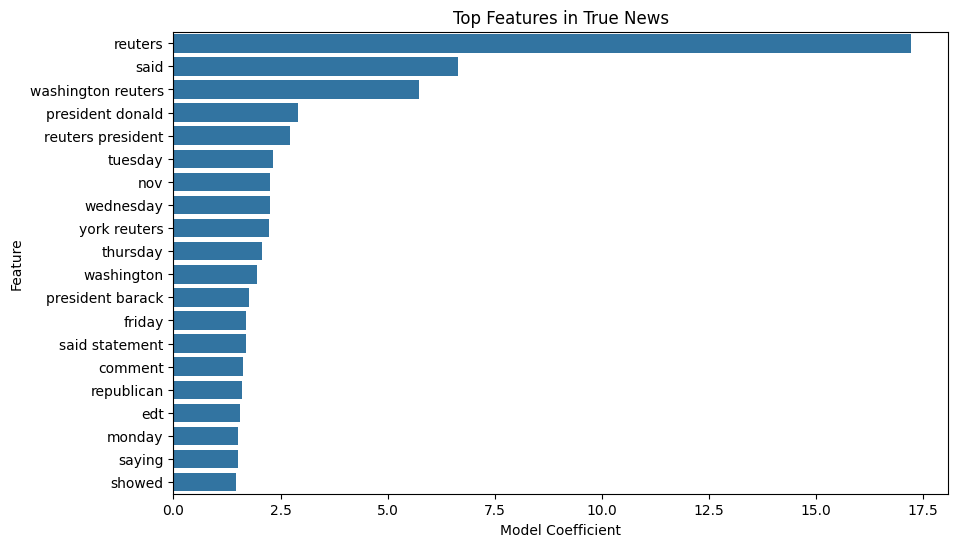

In [162]:
# visualize true news
plt.figure(figsize= (10,6))
sns.barplot(
    data = top_real,
    x = "coefficient",
    y = "feature" )
plt.title("Top Features in True News")
plt.xlabel("Model Coefficient")
plt.ylabel("Feature")

plt.show()

# Task 5: Streamlit Deployment

In [169]:
svm_model = LinearSVC(random_state=42)
final_model = CalibratedClassifierCV(svm_model,cv = 3)
# Train the final model
final_model.fit(X_train, y_train)
print("Final model trained successfully.")

Final model trained successfully.


In [170]:
y_pred = final_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

Accuracy: 0.9937346162452451
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



### Save Model

In [172]:
with open("fake_news_model.pkl", "wb") as file:
    pickle.dump(final_model, file)
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)
print("Model saved successfully.")
print("TF-IDF vectorizer saved successfully.")

Model saved successfully.
TF-IDF vectorizer saved successfully.


In [173]:
from google.colab import files
files.download("fake_news_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>